In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

In [2]:
df = pd.read_csv('data/processed/panel_final.csv', low_memory=False)
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

1,383,526 observations, 133 colonnes


In [3]:
cols_insee = [col for col in df.columns if 'indice' in col or 'chomage' in col]
print(cols_insee)

FEATURES_SANS_INSEE = [f for f in FEATURES if f not in cols_insee]

x_train, x_test, y_train, y_test = split_data(df, features=FEATURES_SANS_INSEE)

['indice_prix_conso', 'indice_prix_conso_complementaires_sante', 'indice_confiance_menages', 'taux_chomage']
Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)



Modèle : RandomForestClassifier
AUC-ROC   : 0.4465  — aire sous la courbe ROC
AUC-PR    : 0.0157  — aire sous la courbe Précision-Recall (plus fiable avec classes déséquilibrées)
Recall    : 0.0018  — taux de résiliants détectés
Précision : 0.0013  — part de vrais résiliants parmi les alertes
F1        : 0.0015  — équilibre recall/précision
F2        : 0.0017  — pénalise davantage les faux négatifs
MCC       : -0.0198  — robuste au déséquilibre des classes
Brier     : 0.0757  — calibration des probabilités (plus bas = mieux)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98    375637
           1       0.00      0.00      0.00      6706

    accuracy                           0.96    382343
   macro avg       0.49      0.49      0.49    382343
weighted avg       0.96      0.96      0.96    382343



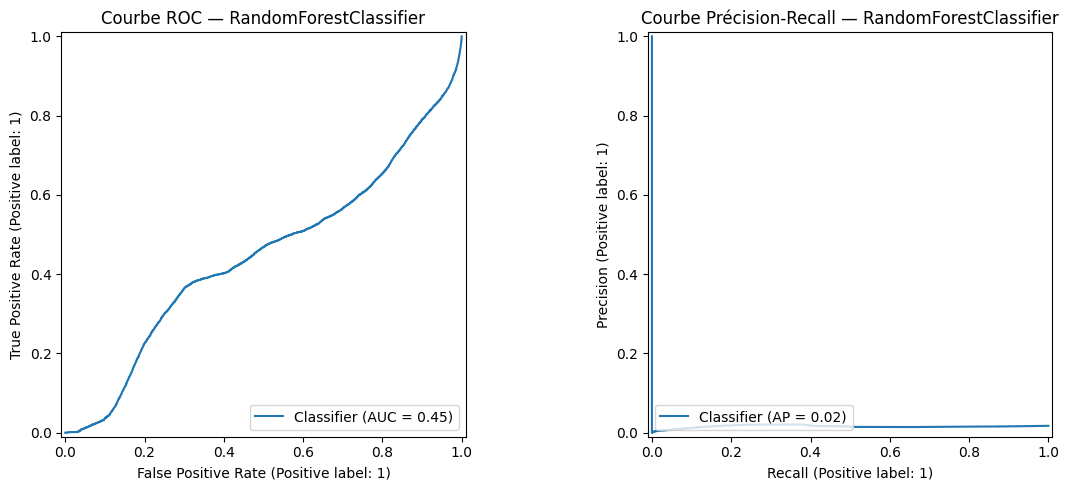

Modèle sauvegardé dans models/random_forest.pkl


'models/random_forest.pkl'

In [6]:
model_rf_sans_insee = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

model_rf_sans_insee.fit(x_train, y_train)
metrics = evaluate(model_rf_sans_insee, x_test, y_test)
save_model(model_rf_sans_insee,'random_forest')

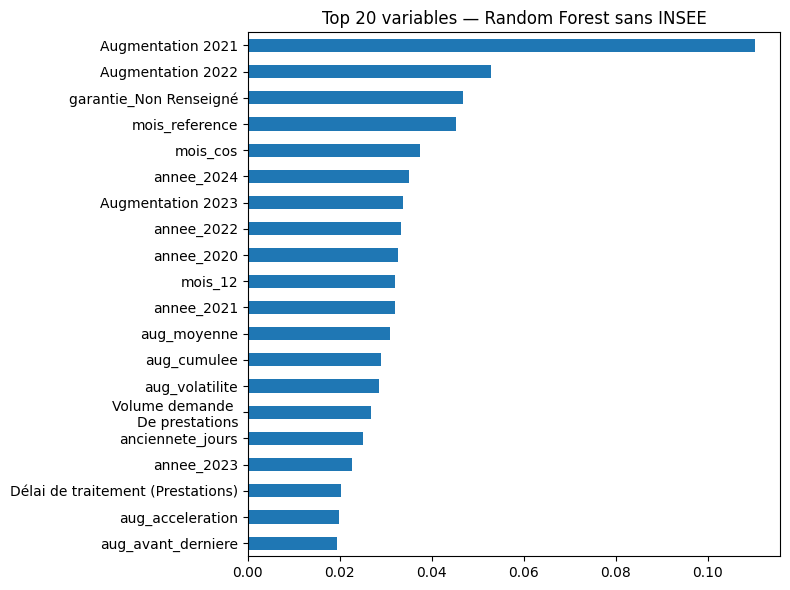

In [7]:
importances = pd.Series(model_rf_sans_insee.feature_importances_, index=FEATURES_SANS_INSEE)
importances.sort_values(ascending=False).head(20).plot(
    kind='barh', figsize=(8, 6)
)
plt.title('Top 20 variables — Random Forest sans INSEE')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()